# Ring Galaxy Detection in Euclid Images


## 1. Imports

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from datasets import load_dataset
from PIL import Image


print('TensorFlow version:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.16.1
GPU available: True


## 2. Load the gz_rings dataset


In [22]:
ds = load_dataset('mwalmsley/gz_rings')
print(ds)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 73356
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 18340
    })
})


0.20000000298023224
<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=424x424 at 0x5A84ED790>


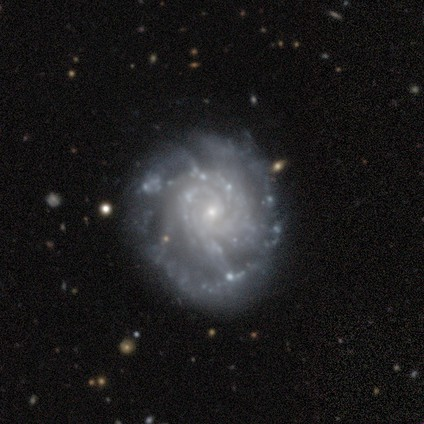

In [23]:
# Data inspecting
labels = ds['train']['label'][10]          
print(labels)      

an_image = ds['train']['image'][10]          
print(an_image)  
display(an_image) 

In [24]:
# Data inspecting
sample = ds['train'][10]
print('Keys:', list(sample.keys()))
print('Label (ring probability):', sample['label'])
print('Image type:', type(sample['image']))
print('Image size:', sample['image'].size)
print('Image mode:', sample['image'].mode)

Keys: ['image', 'label']
Label (ring probability): 0.20000000298023224
Image type: <class 'PIL.JpegImagePlugin.JpegImageFile'>
Image size: (424, 424)
Image mode: RGB


Train samples: 73356
Test samples:  18340

Label stats (train):
  Min:  0.0
  Max:  1.0
  Mean: 0.4722193821770444


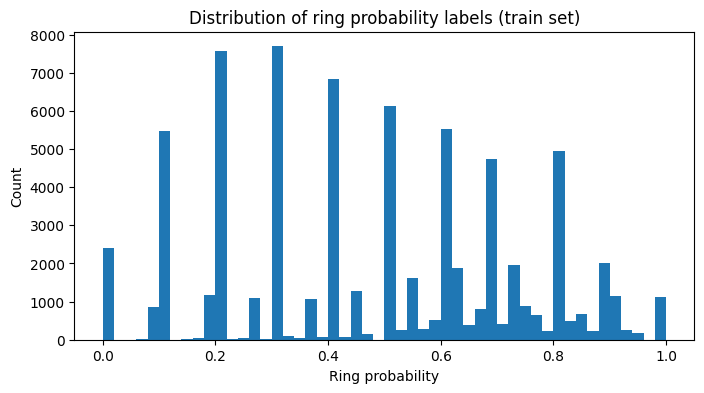

In [25]:
# Dataset split sizes
print('Train samples:', len(ds['train']))
print('Test samples: ', len(ds['test']))

# Label distribution
train_labels = np.array(ds['train']['label'])
print('\nLabel stats (train):')
print('  Min: ', train_labels.min())
print('  Max: ', train_labels.max())
print('  Mean:', train_labels.mean())

plt.figure(figsize=(8, 4))
plt.hist(train_labels, bins=50)
plt.xlabel('Ring probability')
plt.ylabel('Count')
plt.title('Distribution of ring probability labels (train set)')
plt.show()

## 3. Visualize some examples

Plot a few galaxies with high ring probability vs low ring probability to get a feel for the data.

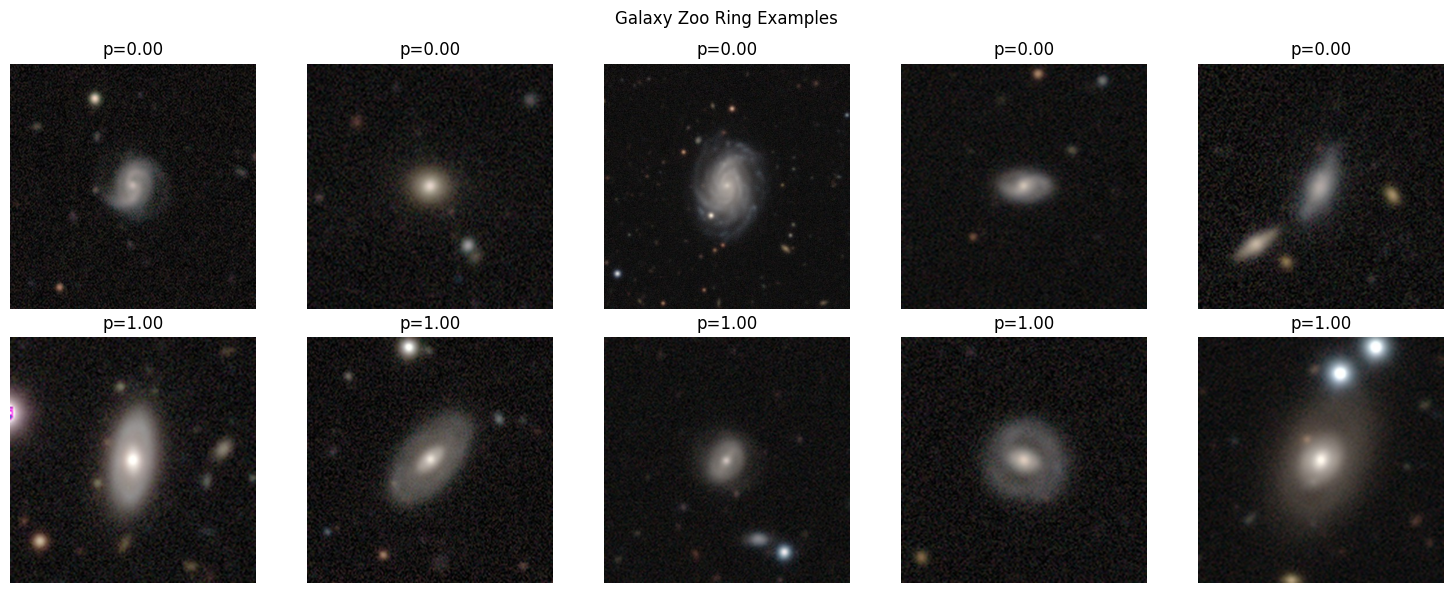

In [26]:
# Sort by label to find high and low ring probability examples
indices = np.argsort(train_labels)

low_ring_indices  = indices[:5]   # lowest ring probability
high_ring_indices = indices[-5:]  # highest ring probability

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, idx in enumerate(low_ring_indices):
    axes[0, i].imshow(ds['train'][int(idx)]['image'])
    axes[0, i].set_title(f"p={train_labels[idx]:.2f}")
    axes[0, i].axis('off')

for i, idx in enumerate(high_ring_indices):
    axes[1, i].imshow(ds['train'][int(idx)]['image'])
    axes[1, i].set_title(f"p={train_labels[idx]:.2f}")
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Low ring prob', fontsize=12)
axes[1, 0].set_ylabel('High ring prob', fontsize=12)
plt.suptitle('Galaxy Zoo Ring Examples')
plt.tight_layout()
plt.show()

## 4. Preprocessing with lazy tf.data pipeline

We use tf.data.Dataset.from_generator() so images are loaded one at a time as the model needs them, never all at once in RAM.

In [27]:
IMG_SIZE   = 224
BATCH_SIZE = 32

# Randomly shuffle before selecting subset
shuffled_train = ds['train'].shuffle(seed=42)

TRAIN_LIMIT = 20000
VAL_LIMIT   = 4000
TEST_LIMIT  = 4000

def make_dataset(hf_split, shuffle=False):          #Load images one at a time using a generator

    def gen():
        for sample in hf_split:
            img = np.array(
                sample['image'].resize((IMG_SIZE, IMG_SIZE)).convert('RGB'),
                dtype=np.float32
            )
            # Use ResNet50's expected preprocessing (scales to [-1, 1] using ImageNet stats)
            # This is critical — ResNet was NOT trained on [0,1] images
            img = keras.applications.resnet.preprocess_input(img)
            yield img, np.float32(sample['label'])

    dataset = tf.data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.float32)
        )
    )

    if shuffle:
        dataset = dataset.shuffle(buffer_size=500, seed=42)

    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


print(f'Train samples:      {TRAIN_LIMIT}')
print(f'Validation samples: {VAL_LIMIT}')
print(f'Test samples:       {TEST_LIMIT}')

train_ds = make_dataset(shuffled_train.select(range(TRAIN_LIMIT)), shuffle=True)
val_ds   = make_dataset(shuffled_train.select(range(TRAIN_LIMIT, TRAIN_LIMIT + VAL_LIMIT)))
test_ds  = make_dataset(ds['test'].select(range(TEST_LIMIT)))

y_test_all = np.array(ds['test'].select(range(TEST_LIMIT))['label'], dtype=np.float32)

print('Datasets ready.')

Train samples:      20000
Validation samples: 4000
Test samples:       4000
Datasets ready.


## 5. Build model with pretrained ResNet50 + custom layer

We use ResNet50 pretrained on ImageNet as the backbone. The backbone already knows how to detect edges, curves, and shapes. We replace its final classification layer with a single neuron (sigmoid) for ring probability regression.

In [29]:
# Load pretrained ResNet50, excluding its top classification layer
backbone = keras.applications.ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Unfreeze the last 30 layers 
backbone.trainable = True
for layer in backbone.layers[:-30]:
    layer.trainable = False

# Build the full model
inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
# training=True: frozen BN layers still use stored stats (trainable=False overrides),
# but unfrozen BN layers in the last 30 will adapt their statistics to galaxy images
x = backbone(inputs, training=True)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs, outputs)

# Count trainable vs frozen parameters
trainable = sum([tf.size(w).numpy() for w in model.trainable_weights])
total     = sum([tf.size(w).numpy() for w in model.weights])
print(f'Trainable params: {trainable:,} / {total:,}')
model.summary()


Trainable params: 14,712,577 / 23,850,113


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 14,712,577 (56.12 MB)

 Non-trainable params: 9,137,536 (34.86 MB)

## 6. Train

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="mse",
    metrics=["mae"]
)

history = model.fit(
    train_ds,
    epochs=12,
    validation_data=val_ds,
    verbose=1
)


Epoch 1/12


2026-04-18 17:40:55.787431: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


    625/Unknown 335s 521ms/step - loss: 0.0814 - mae: 0.2260

2026-04-18 17:46:28.289253: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[StatefulPartitionedCall/gradient_tape/functional_1/global_average_pooling2d_1/mod/_235]]
2026-04-18 17:46:28.289426: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2026-04-18 17:46:28.289708: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 14058238343385775450
2026-04-18 17:46:28.289712: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 11121850792250343499
2026-04-18 17:46:28.289716: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 2544031700727496970
2026-04-18 17:46:28.289718: I tensorflow/core/framework/local_rendezvous.cc:422] Local ren

625/625 ━━━━━━━━━━━━━━━━━━━━ 378s 591ms/step - loss: 0.0745 - mae: 0.2161 - val_loss: 0.0509 - val_mae: 0.1776
Epoch 2/12


...

2026-04-18 18:46:44.764547: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2026-04-18 18:46:44.764625: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[StatefulPartitionedCall/Shape/_6]]


625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - loss: 0.0188 - mae: 0.1070

2026-04-18 18:51:51.919935: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[StatefulPartitionedCall/gradient_tape/functional_1/global_average_pooling2d_1/mod/_235]]
2026-04-18 18:51:51.920431: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 14058238343385775450
2026-04-18 18:51:51.920440: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 2544031700727496970
2026-04-18 18:51:51.920444: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 15928367715081126172
2026-04-18 18:51:51.920448: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 13934588319981929468
2026-04-18 18:51:51.920451: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key h

625/625 ━━━━━━━━━━━━━━━━━━━━ 347s 552ms/step - loss: 0.0179 - mae: 0.1044 - val_loss: 0.0411 - val_mae: 0.1582


2026-04-18 18:52:31.438078: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2026-04-18 18:52:31.438295: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_4]]
2026-04-18 18:52:31.438309: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 1885530510854727009
2026-04-18 18:52:31.438313: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 783608470164348695
2026-04-18 18:52:31.438556: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 16415003949607121434


In [ ]:
# Save model so it can be reloaded without long retrain
model.save('ring_galaxy_model.keras')
print('Model saved.')


Model saved.


In [ ]:
# Reload model if kernel crash
# model = keras.models.load_model("ring_galaxy_model.keras")
# print("Model loaded.")


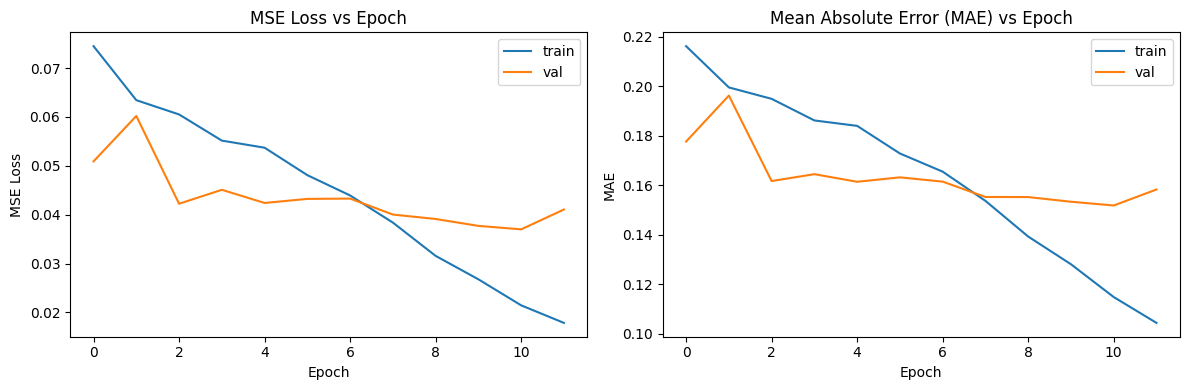

In [ ]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("MSE Loss vs Epoch")
axes[0].legend()

axes[1].plot(history.history["mae"], label="train")
axes[1].plot(history.history["val_mae"], label="val")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].set_title("Mean Absolute Error (MAE) vs Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Evaluate on test set

2026-04-18 18:59:01.857942: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2026-04-18 18:59:01.857989: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_4]]
2026-04-18 18:59:01.857995: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 1885530510854727009
2026-04-18 18:59:01.857999: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 783608470164348695
2026-04-18 18:59:01.858416: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 16415003949607121434


Test MSE: 0.0402
Test MAE: 0.1563
125/125 ━━━━━━━━━━━━━━━━━━━━ 51s 345ms/step


2026-04-18 18:59:52.849600: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


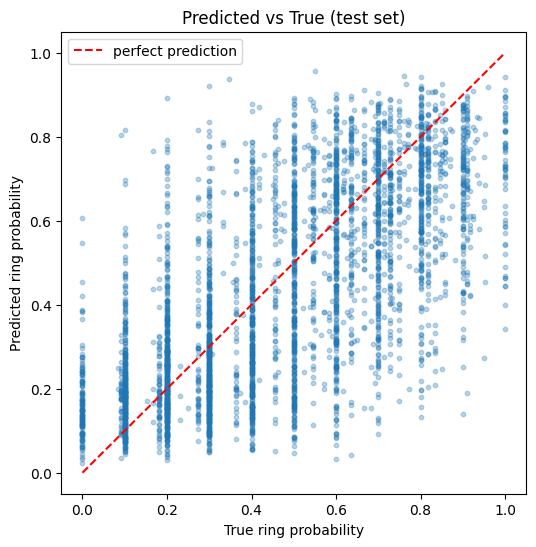

In [ ]:
test_loss, test_mae = model.evaluate(test_ds, verbose=0)
print(f'Test MSE: {test_loss:.4f}')
print(f'Test MAE: {test_mae:.4f}')                                                                                          
                                            
# Predicted vs actual                                                                                                       
y_pred = model.predict(test_ds).flatten()                 
                                                                                                                            
plt.figure(figsize=(6, 6))              
plt.scatter(y_test_all, y_pred, alpha=0.3, s=10)                                                                            
plt.plot([0, 1], [0, 1], 'r--', label='perfect prediction')                                                                 
plt.xlabel('True ring probability')         
plt.ylabel('Predicted ring probability')                                                                                    
plt.title('Predicted vs True (test set)')                                                                                   
plt.legend()                                                                                                                
plt.show()                        

## 8. Inference on Euclid images



In [ ]:
# Load only the test split (2,378 images) 
ds_euclid = load_dataset('mwalmsley/gz_euclid', split='test')
print(ds_euclid)


Dataset({
    features: ['image', 'id_str', 'dataset_name', 'smooth-or-featured-euclid_smooth', 'smooth-or-featured-euclid_smooth_fraction', 'smooth-or-featured-euclid_total-votes', 'smooth-or-featured-euclid_featured-or-disk', 'smooth-or-featured-euclid_featured-or-disk_fraction', 'smooth-or-featured-euclid_problem', 'smooth-or-featured-euclid_problem_fraction', 'disk-edge-on-euclid_yes', 'disk-edge-on-euclid_yes_fraction', 'disk-edge-on-euclid_total-votes', 'disk-edge-on-euclid_no', 'disk-edge-on-euclid_no_fraction', 'has-spiral-arms-euclid_yes', 'has-spiral-arms-euclid_yes_fraction', 'has-spiral-arms-euclid_total-votes', 'has-spiral-arms-euclid_no', 'has-spiral-arms-euclid_no_fraction', 'bar-euclid_strong', 'bar-euclid_strong_fraction', 'bar-euclid_total-votes', 'bar-euclid_weak', 'bar-euclid_weak_fraction', 'bar-euclid_no', 'bar-euclid_no_fraction', 'bulge-size-euclid_dominant', 'bulge-size-euclid_dominant_fraction', 'bulge-size-euclid_total-votes', 'bulge-size-euclid_large', 'bulg

In [ ]:
print('Loading Euclid images (test split only)...')
X_euclid      = []
X_euclid_disp = []
euclid_ids    = []

for sample in ds_euclid:
    img_raw = np.array(
        sample["image"].resize((IMG_SIZE, IMG_SIZE)).convert("RGB"),
        dtype=np.float32
    )
    X_euclid_disp.append(img_raw / 255.0)
    X_euclid.append(keras.applications.resnet.preprocess_input(img_raw.copy()))
    euclid_ids.append(sample.get("id_str", ""))

X_euclid      = np.array(X_euclid)
X_euclid_disp = np.array(X_euclid_disp)
print('X_euclid shape:', X_euclid.shape)


Loading Euclid images (test split only)...
X_euclid shape: (2378, 224, 224, 3)


In [ ]:
# Run prediction and rank by score
euclid_scores  = model.predict(X_euclid, batch_size=32).flatten()
ranked_indices = np.argsort(euclid_scores)[::-1]

print('Top 10 ring candidates:')
for i in range(10):
    idx = ranked_indices[i]
    print(f"  Rank {i+1}: index={idx}, score={euclid_scores[idx]:.4f}")


75/75 ━━━━━━━━━━━━━━━━━━━━ 64s 411ms/step
Top 10 ring candidates:
  Rank 1: index=1423, score=0.8636
  Rank 2: index=879, score=0.8615
  Rank 3: index=2032, score=0.8584
  Rank 4: index=1465, score=0.8545
  Rank 5: index=1907, score=0.8475
  Rank 6: index=1253, score=0.8348
  Rank 7: index=630, score=0.8268
  Rank 8: index=962, score=0.8171
  Rank 9: index=743, score=0.8165
  Rank 10: index=2224, score=0.8131


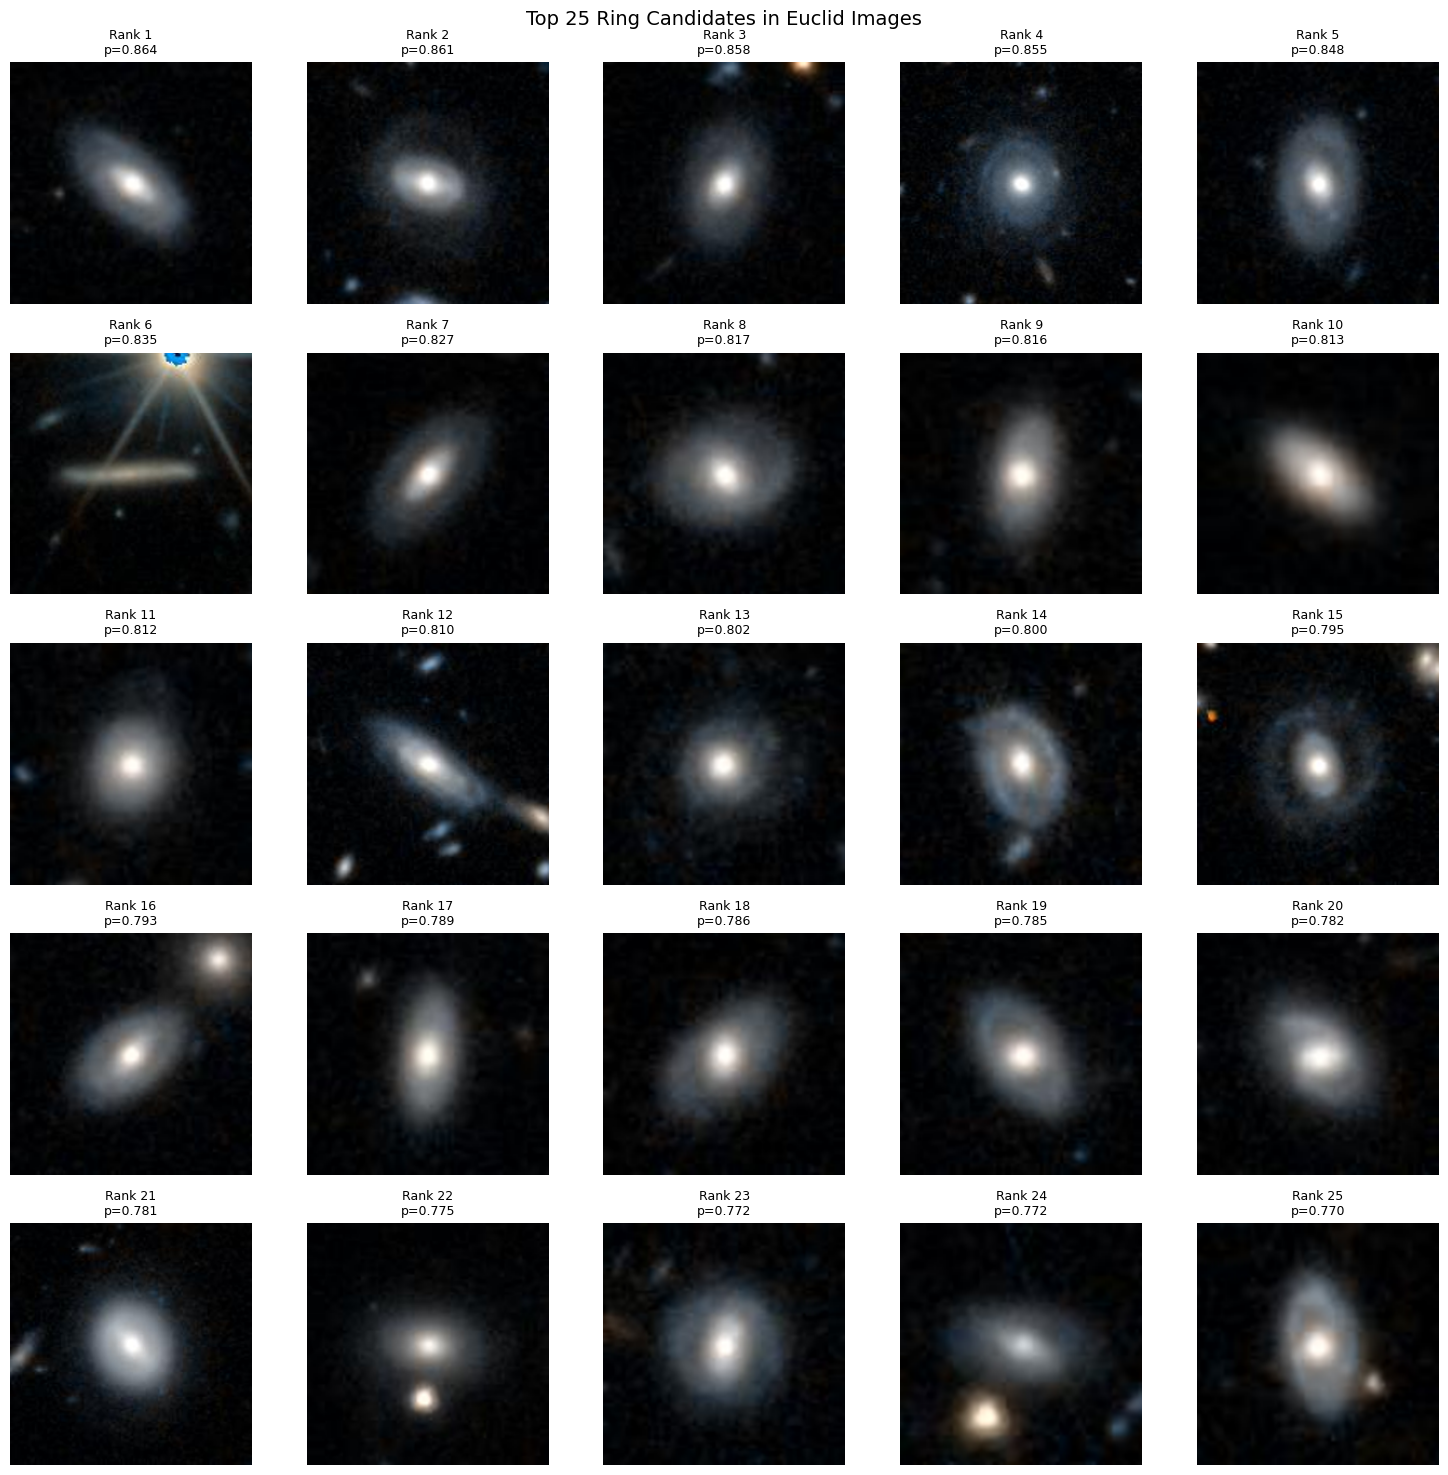

In [ ]:
# Visualize top 25 
fig, axes = plt.subplots(5, 5, figsize=(15, 15))

for i, ax in enumerate(axes.flat):
    idx = ranked_indices[i]
    ax.imshow(X_euclid_disp[idx])
    ax.set_title(f"Rank {i+1}\np={euclid_scores[idx]:.3f}", fontsize=9)
    ax.axis("off")

plt.suptitle('Top 25 Ring Candidates in Euclid Images', fontsize=14)
plt.tight_layout()
plt.show()


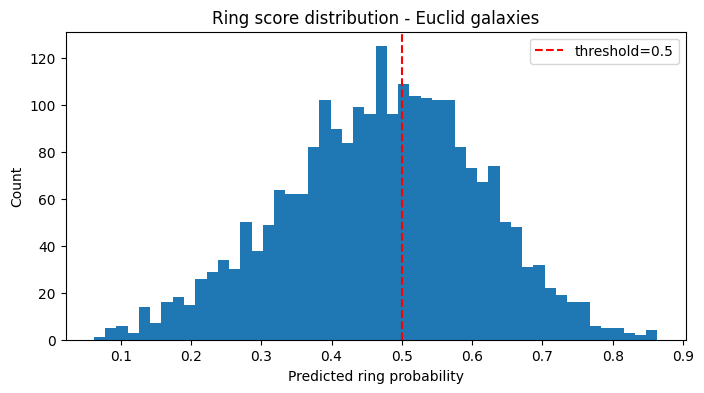

Galaxies with score > 0.5: 1044 / 2378


In [ ]:
# Histogram of predicted probability on Euclid dataset
plt.figure(figsize=(8, 4))
plt.hist(euclid_scores, bins=50)
plt.xlabel('Predicted ring probability')
plt.ylabel('Count')
plt.title('Ring score distribution - Euclid galaxies')
plt.axvline(0.5, color='r', linestyle='--', label='threshold=0.5')
plt.legend()
plt.show()

print(f'Galaxies with score > 0.5: {(euclid_scores > 0.5).sum()} / {len(euclid_scores)}')
